 1.Importing the Dependencies

In [1]:
# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Date/time handling
import datetime as dt

# Ignore warnings (optional)
import warnings
warnings.filterwarnings("ignore")


2. Data Loading and Understanding

In [2]:

import pandas as pd

# Chicago Crime dataset - pull from City of Chicago API
# Filtering: crimes from 2019 onwards (~5 years of data)
url = "https://data.cityofchicago.org/resource/ijzp-q8t2.csv?$where=date>'2019-01-01T00:00:00'&$limit=500000"

# Read into pandas
df = pd.read_csv(url)

print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()



Dataset shape: (500000, 22)
Columns: ['id', 'case_number', 'date', 'block', 'iucr', 'primary_type', 'description', 'location_description', 'arrest', 'domestic', 'beat', 'district', 'ward', 'community_area', 'fbi_code', 'x_coordinate', 'y_coordinate', 'year', 'updated_on', 'latitude', 'longitude', 'location']


,id,case_number,date,block,iucr,primary_type,description,location_description,arrest,domestic,...,ward,community_area,fbi_code,x_coordinate,y_coordinate,year,updated_on,latitude,longitude,location
0,14037817,JJ500223,2025-11-24T00:00:00.000,004XX N LAVERGNE AVE,051A,ASSAULT,AGGRAVATED - HANDGUN,ALLEY,False,False,...,37.0,25.0,04A,1142958.0,1902468.0,2025,2025-12-01T15:42:34.000,41.888417,-87.750464,"\n, \n(41.8884167, -87.75046436)"
1,14039161,JJ501764,2025-11-24T00:00:00.000,073XX S DAMEN AVE,0810,THEFT,OVER $500,STREET,False,False,...,17.0,67.0,06,1164295.0,1855986.0,2025,2025-12-01T15:42:34.000,41.760441,-87.673418,"\n, \n(41.760440542, -87.673418209)"
2,14039091,JJ501772,2025-11-24T00:00:00.000,049XX N KENMORE AVE,0560,ASSAULT,SIMPLE,RESIDENCE - PORCH / HALLWAY,False,False,...,48.0,3.0,08A,1168355.0,1933247.0,2025,2025-12-01T15:42:34.000,41.972365,-87.656305,"\n, \n(41.972364558, -87.656304974)"
3,14039563,JJ502116,2025-11-24T00:00:00.000,037XX S LAKE PARK AVE,0920,MOTOR VEHICLE THEFT,ATTEMPT - AUTOMOBILE,STREET,False,False,...,4.0,36.0,07,1182528.0,1880753.0,2025,2025-12-01T15:42:34.000,41.828000,-87.605826,"\n, \n(41.828000054, -87.605825961)"
4,14038951,JJ501528,2025-11-24T00:00:00.000,048XX S ELLIS AVE,0910,MOTOR VEHICLE THEFT,AUTOMOBILE,STREET,False,False,...,4.0,39.0,07,1183729.0,1873225.0,2025,2025-12-01T15:42:34.000,41.807315,-87.601655,"\n, \n(41.807314691, -87.601654864)"


In [3]:
# Convert 'date' column to datetime
df['date'] = pd.to_datetime(df['date'])

# Extract features
df['hour'] = df['date'].dt.hour
df['day_of_week'] = df['date'].dt.day_name()
df['month'] = df['date'].dt.month
df['year'] = df['date'].dt.year

# Quick check
df[['date', 'hour', 'day_of_week', 'month', 'year']].head()


,date,hour,day_of_week,month,year
0,2025-11-24,0,Monday,11,2025
1,2025-11-24,0,Monday,11,2025
2,2025-11-24,0,Monday,11,2025
3,2025-11-24,0,Monday,11,2025
4,2025-11-24,0,Monday,11,2025


Missing Values Overview

In [4]:
df.isnull().sum().sort_values(ascending=False).head(10)


,0
location_description,2126
longitude,2081
latitude,2081
y_coordinate,2081
location,2081
x_coordinate,2081
ward,1
community_area,1
id,0
arrest,0


Exploratory Data Analysis (EDA)

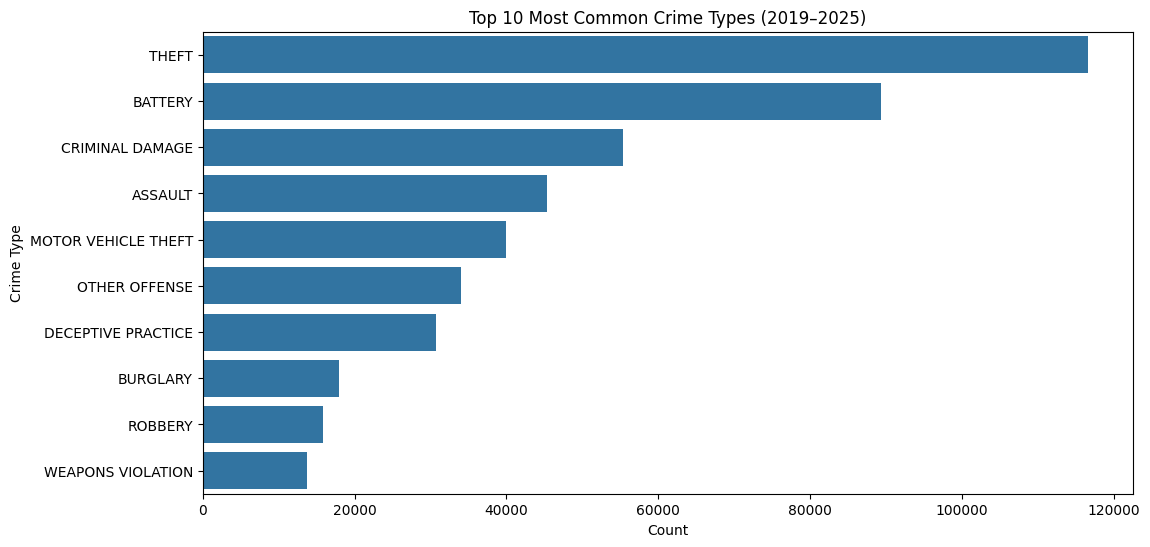

In [5]:
plt.figure(figsize=(12,6))
sns.countplot(data=df, y='primary_type', order=df['primary_type'].value_counts().head(10).index)
plt.title("Top 10 Most Common Crime Types (2019–2025)")
plt.xlabel("Count")
plt.ylabel("Crime Type")
plt.show()


Define a “Hotspot”

In [6]:
# Count crimes by community area
crime_counts = df['community_area'].value_counts()

# Define hotspots as top 10% areas
threshold = crime_counts.quantile(0.90)
hotspots = crime_counts[crime_counts >= threshold].index

# Create hotspot label (1 = hotspot, 0 = not)
df['hotspot'] = df['community_area'].apply(lambda x: 1 if x in hotspots else 0)

df[['community_area','hotspot']].head()


,community_area,hotspot
0,25.0,1
1,67.0,0
2,3.0,0
3,36.0,0
4,39.0,0


In [7]:
# Aggregate daily crime counts
daily_counts = df.groupby('date').size().reset_index(name='crime_count')
daily_counts.head()


,date,crime_count
0,2023-11-22 13:00:00,5
1,2023-11-22 13:12:00,1
2,2023-11-22 13:20:00,1
3,2023-11-22 13:30:00,5
4,2023-11-22 13:31:00,2


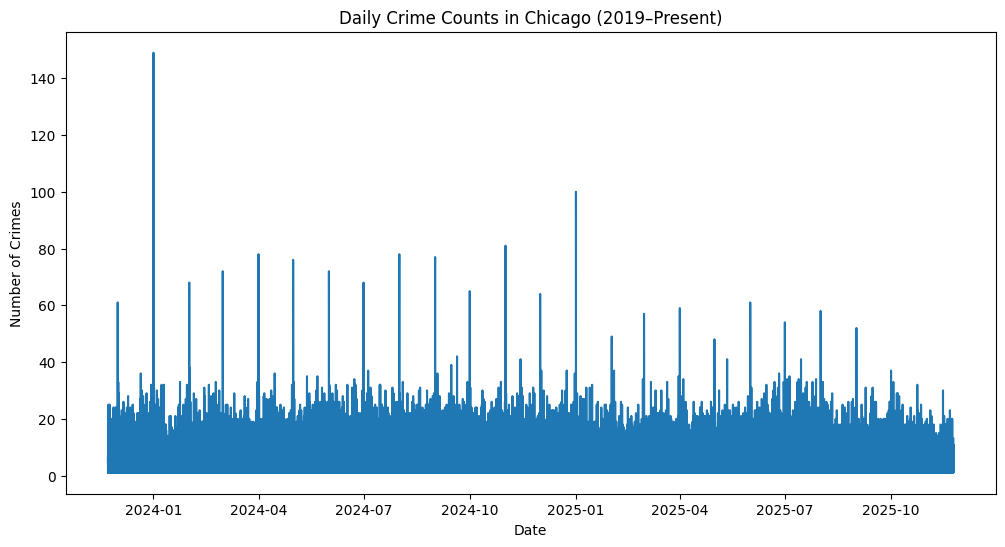

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(daily_counts['date'], daily_counts['crime_count'])
plt.title("Daily Crime Counts in Chicago (2019–Present)")
plt.xlabel("Date")
plt.ylabel("Number of Crimes")
plt.show()


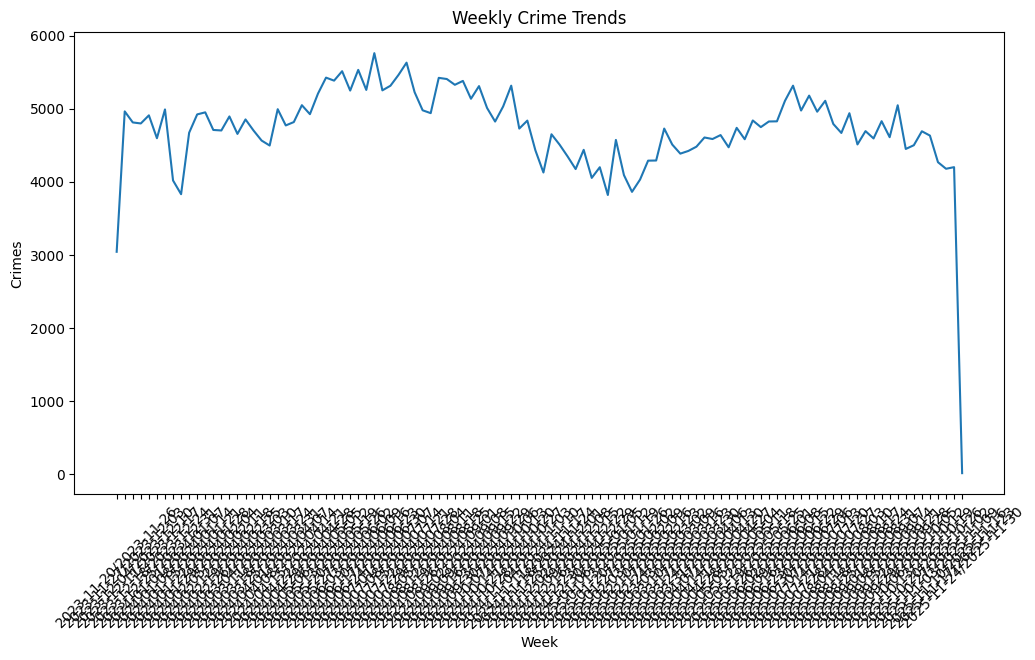

In [9]:
df['week'] = pd.to_datetime(df['date']).dt.to_period('W')
weekly_counts = df.groupby('week').size().reset_index(name='crime_count')

plt.figure(figsize=(12,6))
plt.plot(weekly_counts['week'].astype(str), weekly_counts['crime_count'])
plt.title("Weekly Crime Trends")
plt.xlabel("Week")
plt.ylabel("Crimes")
plt.xticks(rotation=45)
plt.show()


Overview of the Data

In [10]:
# Basic info
df.info()

# Summary statistics
df.describe()

# Check for missing values
df.isnull().sum().sort_values(ascending=False)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 27 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   id                    500000 non-null  int64         
 1   case_number           500000 non-null  object        
 2   date                  500000 non-null  datetime64[ns]
 3   block                 500000 non-null  object        
 4   iucr                  500000 non-null  object        
 5   primary_type          500000 non-null  object        
 6   description           500000 non-null  object        
 7   location_description  497874 non-null  object        
 8   arrest                500000 non-null  bool          
 9   domestic              500000 non-null  bool          
 10  beat                  500000 non-null  int64         
 11  district              500000 non-null  int64         
 12  ward                  499999 non-null  float64       
 13 

,0
location_description,2126
x_coordinate,2081
y_coordinate,2081
latitude,2081
longitude,2081
location,2081
ward,1
community_area,1
date,0
case_number,0


Distribution of Crimes Over Time

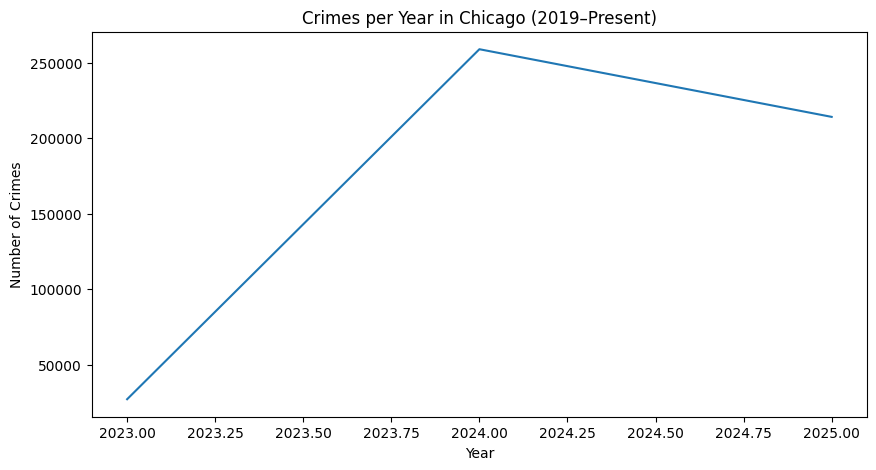

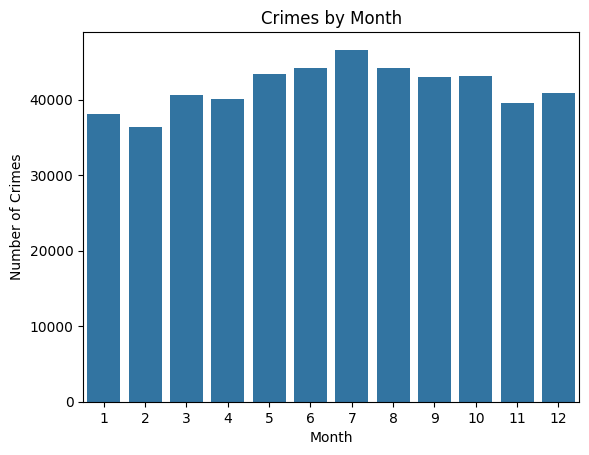

In [11]:
# Crimes per year
df['year'] = pd.to_datetime(df['date']).dt.year
yearly_counts = df['year'].value_counts().sort_index()
plt.figure(figsize=(10,5))
sns.lineplot(x=yearly_counts.index, y=yearly_counts.values)
plt.title("Crimes per Year in Chicago (2019–Present)")
plt.xlabel("Year")
plt.ylabel("Number of Crimes")
plt.show()

# Crimes per month
df['month'] = pd.to_datetime(df['date']).dt.month
monthly_counts = df['month'].value_counts().sort_index()
sns.barplot(x=monthly_counts.index, y=monthly_counts.values)
plt.title("Crimes by Month")
plt.xlabel("Month")
plt.ylabel("Number of Crimes")
plt.show()


Top Crime Types

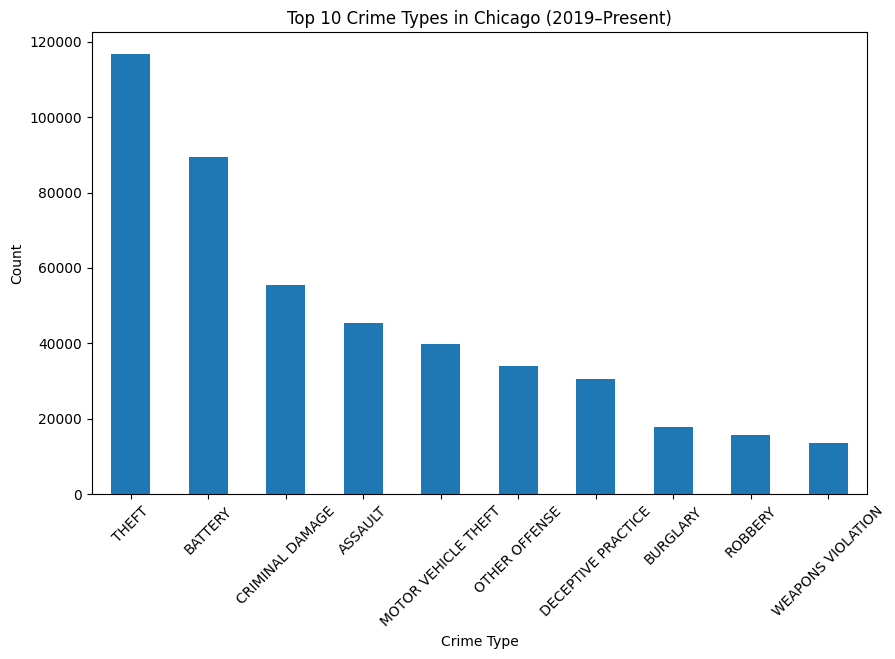

In [12]:
plt.figure(figsize=(10,6))
df['primary_type'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Crime Types in Chicago (2019–Present)")
plt.xlabel("Crime Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()


Crimes by Location Type

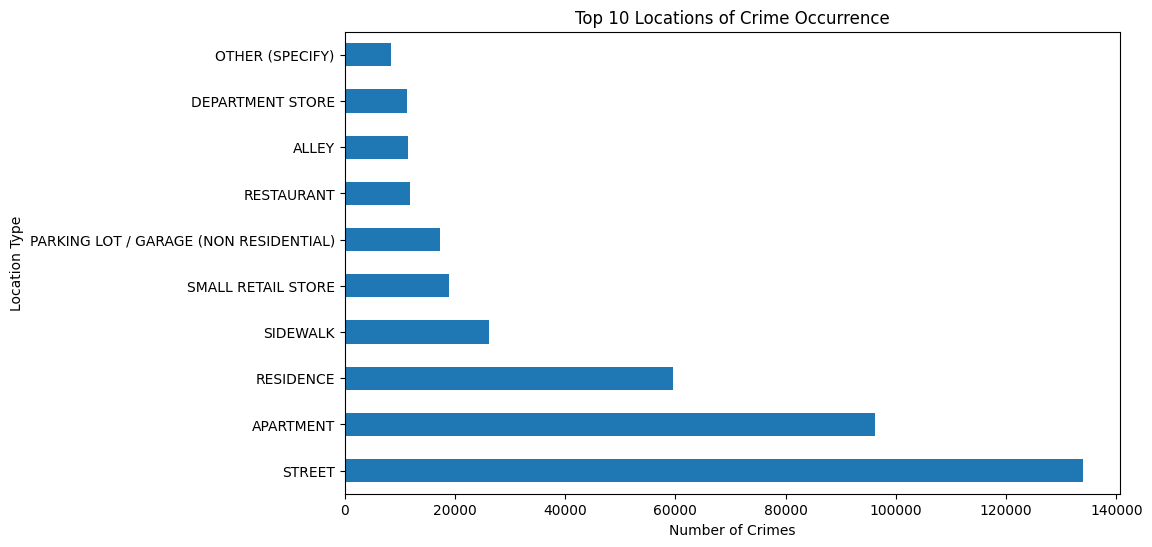

In [13]:
plt.figure(figsize=(10,6))
df['location_description'].value_counts().head(10).plot(kind='barh')
plt.title("Top 10 Locations of Crime Occurrence")
plt.xlabel("Number of Crimes")
plt.ylabel("Location Type")
plt.show()




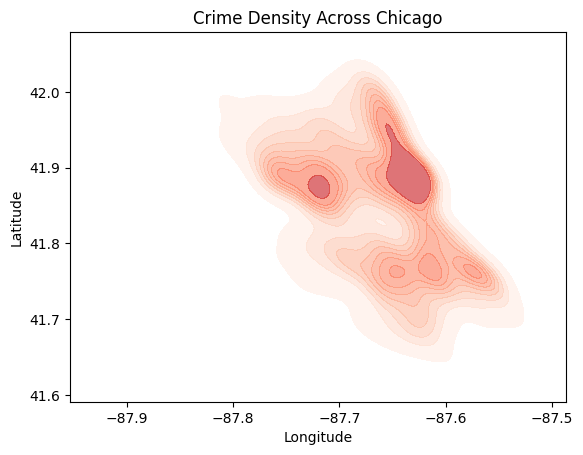

In [14]:
sns.kdeplot(
    data=df.sample(10000),
    x='longitude',
    y='latitude',
    fill=True,
    cmap='Reds',
    alpha=0.6
)
plt.title("Crime Density Across Chicago")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


Arrest and Domestic Patterns

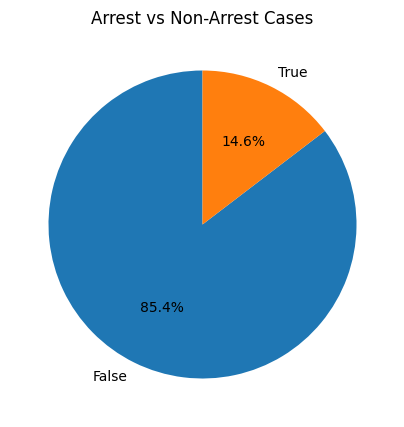

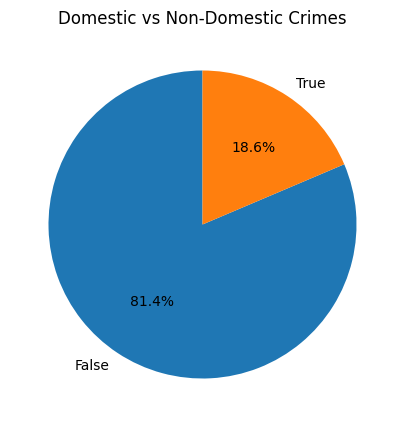

In [15]:
# Arrest ratio
plt.figure(figsize=(5,5))
df['arrest'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title("Arrest vs Non-Arrest Cases")
plt.ylabel("")
plt.show()

# Domestic incidents
plt.figure(figsize=(5,5))
df['domestic'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title("Domestic vs Non-Domestic Crimes")
plt.ylabel("")
plt.show()


Crimes by Community Area

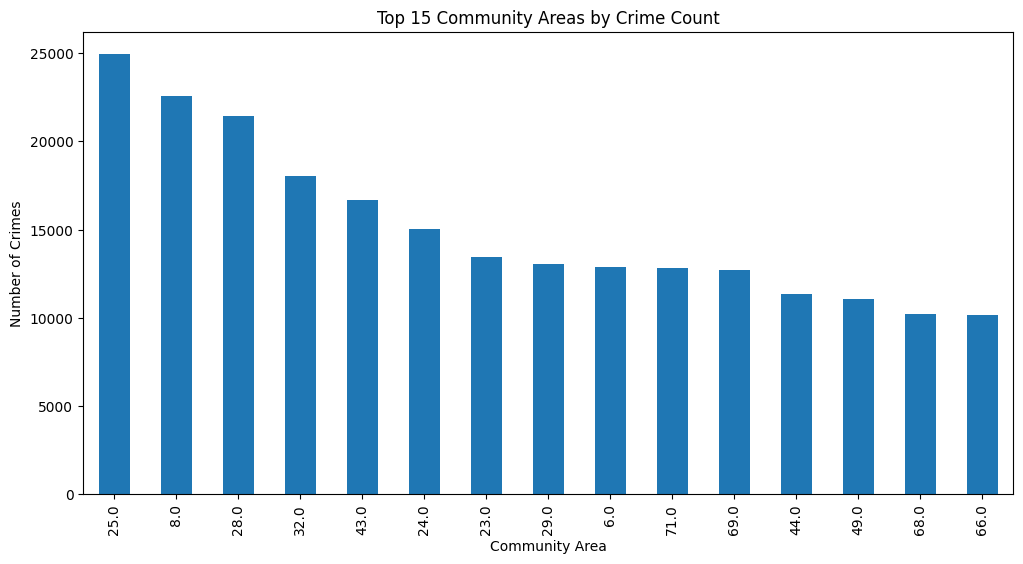

In [16]:
plt.figure(figsize=(12,6))
df['community_area'].value_counts().head(15).plot(kind='bar')
plt.title("Top 15 Community Areas by Crime Count")
plt.xlabel("Community Area")
plt.ylabel("Number of Crimes")
plt.show()


Temporal Trends by Day and Hour

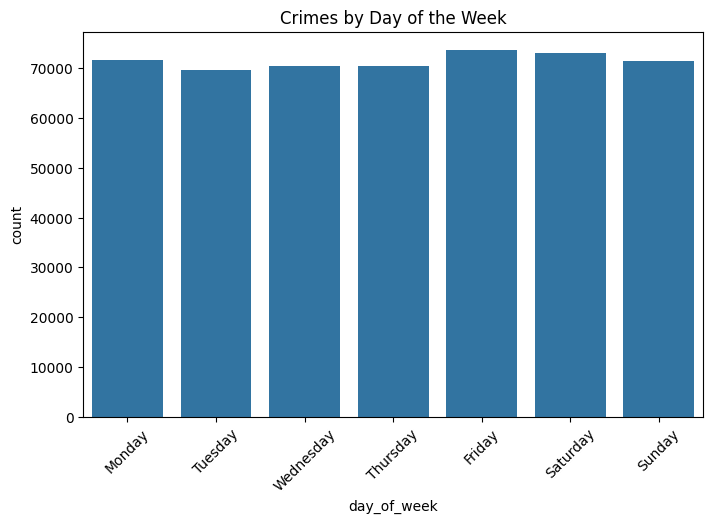

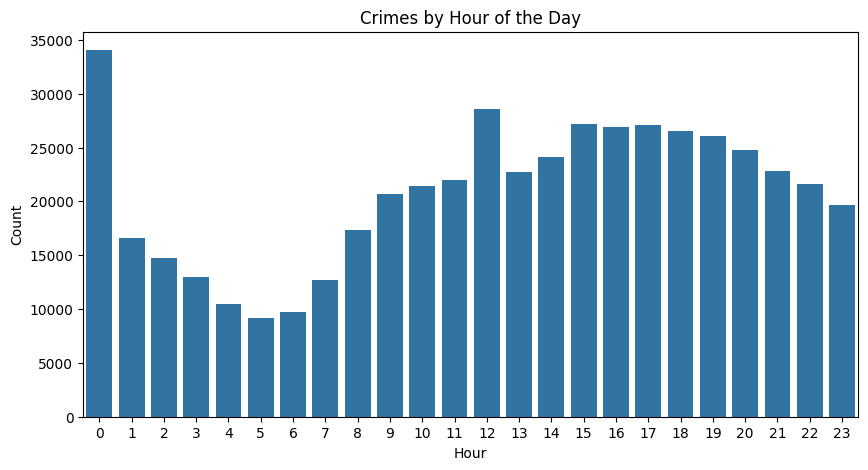

In [17]:
df['day_of_week'] = pd.to_datetime(df['date']).dt.day_name()
df['hour'] = pd.to_datetime(df['date']).dt.hour

# Day of week
plt.figure(figsize=(8,5))
sns.countplot(x='day_of_week', data=df, order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
plt.title("Crimes by Day of the Week")
plt.xticks(rotation=45)
plt.show()

# Hour of day
plt.figure(figsize=(10,5))
sns.countplot(x='hour', data=df)
plt.title("Crimes by Hour of the Day")
plt.xlabel("Hour")
plt.ylabel("Count")
plt.show()


Correlation Heatmap (for Numeric Columns)

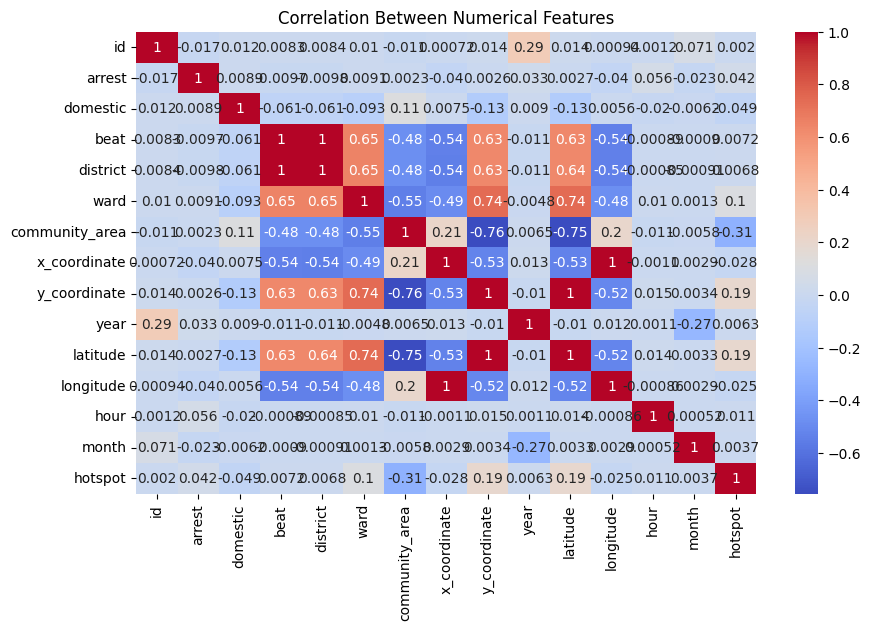

In [18]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Between Numerical Features")
plt.show()


Geospatial Visualization

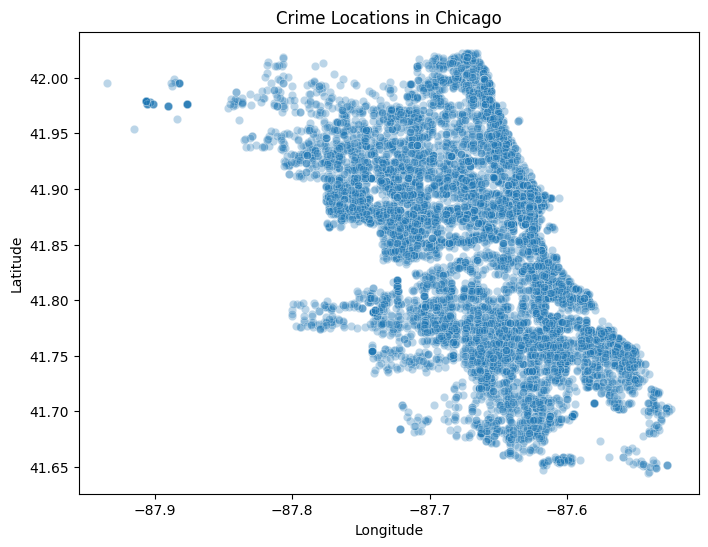

In [19]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='longitude', y='latitude', data=df.sample(10000), alpha=0.3)
plt.title("Crime Locations in Chicago")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


### Key Insights from EDA
- Most crimes occur in [Top 3 areas].
- Crime rates were highest in [Year] and decreased in [Year].
- Theft and battery are the most frequent crime types.
- Street and residence are the most common crime locations.
- Spatial density maps show high concentration in central and south Chicago regions.
- This exploratory analysis will guide the hotspot and forecasting models in the next phase.


In [21]:
# Build classification dataframe
clf_df = df[[
    'primary_type',
    'location_description',
    'arrest',
    'domestic',
    'community_area',
    'hour',
    'day_of_week',
    'month',
    'hotspot'
]].dropna()

print("Shape:", clf_df.shape)
clf_df.head()


Shape: (497873, 9)


,primary_type,location_description,arrest,domestic,community_area,hour,day_of_week,month,hotspot
0,ASSAULT,ALLEY,False,False,25.0,0,Monday,11,1
1,THEFT,STREET,False,False,67.0,0,Monday,11,0
2,ASSAULT,RESIDENCE - PORCH / HALLWAY,False,False,3.0,0,Monday,11,0
3,MOTOR VEHICLE THEFT,STREET,False,False,36.0,0,Monday,11,0
4,MOTOR VEHICLE THEFT,STREET,False,False,39.0,0,Monday,11,0


In [22]:
from sklearn.preprocessing import LabelEncoder

categoricals = ['primary_type', 'location_description', 'day_of_week']

le = LabelEncoder()
for col in categoricals:
    clf_df[col] = le.fit_transform(clf_df[col])


In [23]:
from sklearn.model_selection import train_test_split

X = clf_df.drop('hotspot', axis=1)
y = clf_df['hotspot']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)


In [24]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=500)
log_reg.fit(X_train, y_train)

y_pred_lr = log_reg.predict(X_test)


In [25]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    random_state=42
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)


In [26]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)



Logistic Regression Results:
Accuracy: 0.6350087873462215
F1 Score: 0.08834595896252445

Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.87      0.77     70656
           1       0.16      0.06      0.09     28919

    accuracy                           0.64     99575
   macro avg       0.43      0.47      0.43     99575
weighted avg       0.54      0.64      0.57     99575



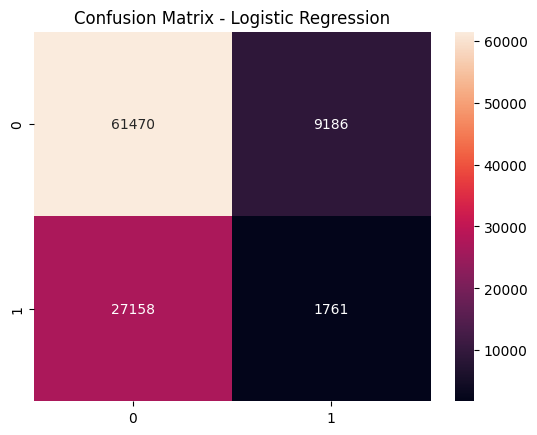


Random Forest Results:
Accuracy: 0.9980015064022094
F1 Score: 0.9965595338946422

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     70656
           1       1.00      1.00      1.00     28919

    accuracy                           1.00     99575
   macro avg       1.00      1.00      1.00     99575
weighted avg       1.00      1.00      1.00     99575



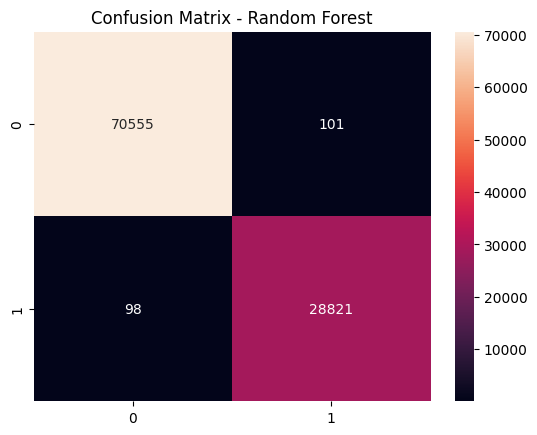


XGBoost Results:
Accuracy: 1.0
F1 Score: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     70656
           1       1.00      1.00      1.00     28919

    accuracy                           1.00     99575
   macro avg       1.00      1.00      1.00     99575
weighted avg       1.00      1.00      1.00     99575



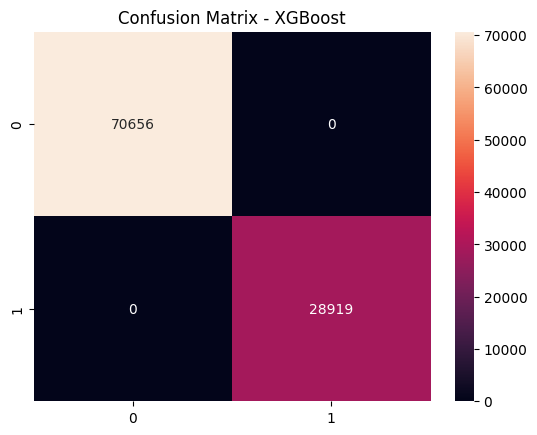

In [27]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

def evaluate_model(name, y_test, y_pred):
    print(f"\n{name} Results:")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

evaluate_model("Logistic Regression", y_test, y_pred_lr)
evaluate_model("Random Forest", y_test, y_pred_rf)
evaluate_model("XGBoost", y_test, y_pred_xgb)


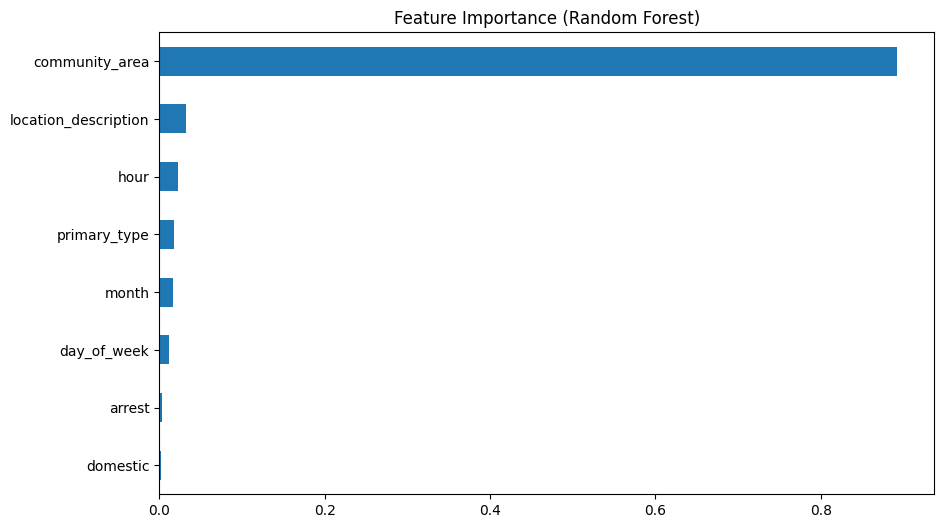

In [28]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh', figsize=(10,6))
plt.title("Feature Importance (Random Forest)")
plt.show()


In [ ]:
B

In [29]:
daily = df.groupby(df['date'].dt.date).size().reset_index(name='crime_count')
daily['date'] = pd.to_datetime(daily['date'])
daily.set_index('date', inplace=True)
daily = daily.asfreq('D').fillna(0)   # fill missing days with 0 crimes
daily.head()


,crime_count
date,
2023-11-22,361
2023-11-23,559
2023-11-24,678
2023-11-25,707
2023-11-26,737


In [30]:
import statsmodels.api as sm

sarima = sm.tsa.statespace.SARIMAX(
    daily['crime_count'],
    order=(2,1,2),
    seasonal_order=(1,1,1,7)  # weekly seasonality
).fit()

sarima.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                      
===========================================================================================
Dep. Variable:                         crime_count   No. Observations:                  734
Model:             SARIMAX(2, 1, 2)x(1, 1, [1], 7)   Log Likelihood               -3958.385
Date:                             Tue, 02 Dec 2025   AIC                           7930.770
Time:                                     20:33:16   BIC                           7962.883
Sample:                                 11-22-2023   HQIC                          7943.162
                                      - 11-24-2025                                         
Covariance Type:                               opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3767      0.348      1.081      0.280      -0.306       1.060
ar.L2          0.1209      0.115      1.047      0.295      -0.105       0.347
ma.L1         -0.9924      0.356     -2.785      0.005      -1.691      -0.294
ma.L2          0.0759      0.309      0.245      0.806      -0.531       0.682
ar.S.L7       -0.0533      0.048     -1.106      0.269      -0.148       0.041
ma.S.L7       -0.9987      0.220     -4.534      0.000      -1.430      -0.567
sigma2      3038.0627    587.764      5.169      0.000    1886.067    4190.059
===================================================================================
Ljung-Box (L1) (Q):                   0.02   Jarque-Bera (JB):             11683.52
Prob(Q):                              0.88   Prob(JB):                         0.00
Heteroskedasticity (H):               1.06   Skew:                            -1.48
Prob(H) (two-sided):                  0.63   Kurtosis:                        22.43
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

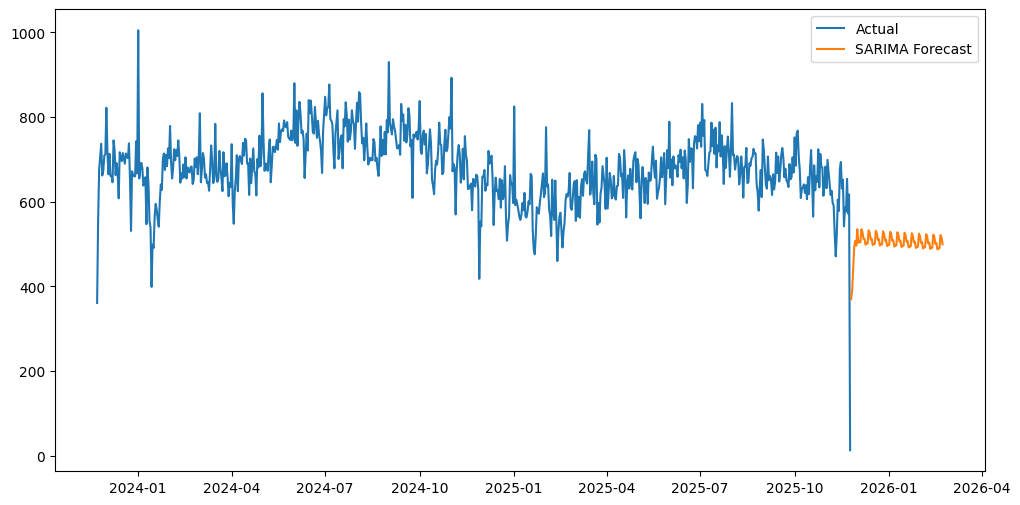

In [31]:
sarima_forecast = sarima.get_forecast(steps=90)
sarima_pred = sarima_forecast.predicted_mean

plt.figure(figsize=(12,6))
plt.plot(daily.index, daily['crime_count'], label='Actual')
plt.plot(sarima_pred.index, sarima_pred.values, label='SARIMA Forecast')
plt.legend()
plt.show()


In [32]:
from prophet import Prophet

pf = daily.reset_index()
pf.columns = ['ds', 'y']


In [33]:
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)

model.fit(pf)


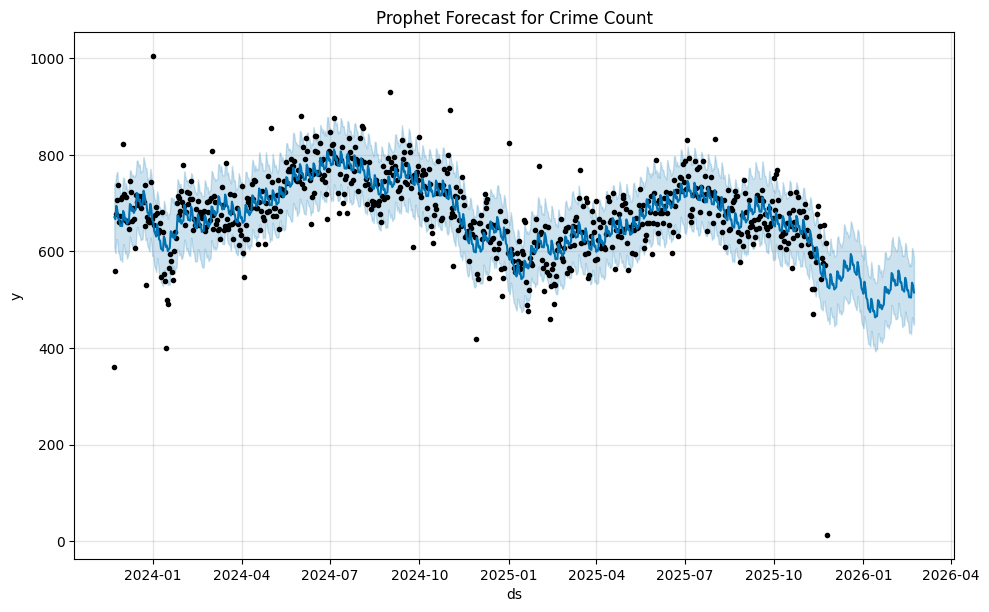

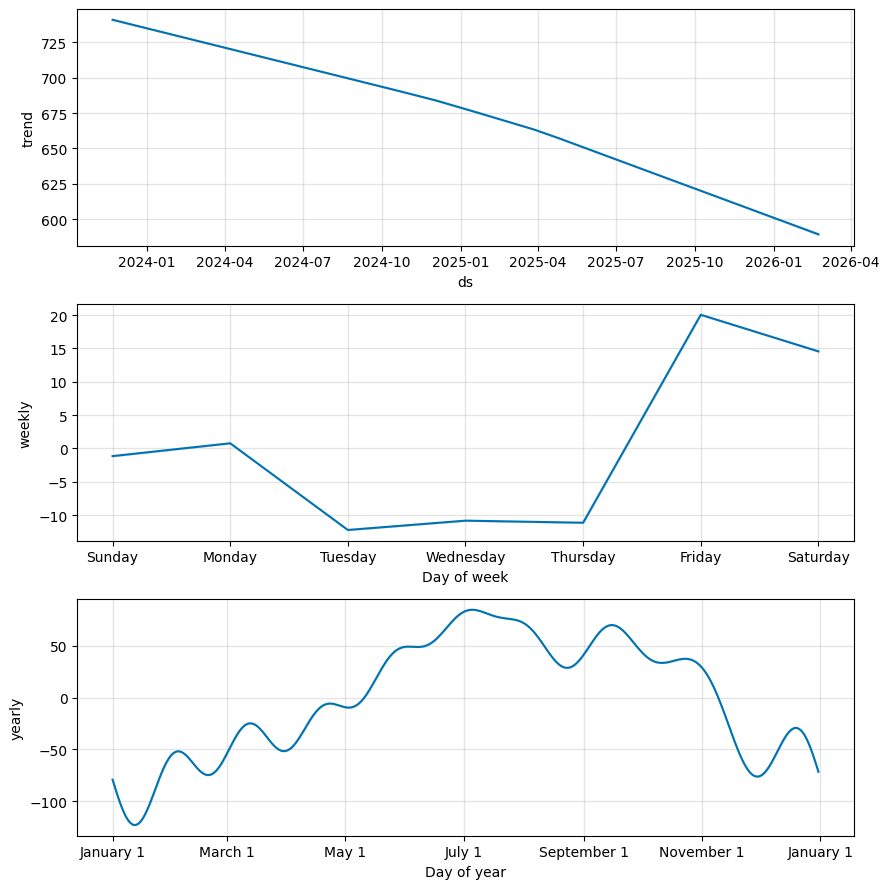

In [34]:
future = model.make_future_dataframe(periods=90)
forecast = model.predict(future)

model.plot(forecast)
plt.title("Prophet Forecast for Crime Count")
plt.show()

model.plot_components(forecast)
plt.show()
